# ❤️ Heart Disease Prediction using Machine Learning

## 📌 Project Overview

Heart disease is one of the leading causes of death worldwide. Early prediction can help healthcare professionals make informed decisions and improve patient outcomes.

In this project, we build a machine learning model to predict whether a patient has heart disease based on clinical and demographic features.

---

## 🎯 Objectives

- Explore and understand the dataset
- Perform data preprocessing
- Train and compare multiple machine learning models
- Evaluate model performance using different metrics
- Explain model predictions using Explainable AI (SHAP)
- Deploy the best model with Streamlit

---

## 🛠 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- SHAP
- Streamlit


#  Import Libraries

In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

#  Load the Dataset

In [3]:
df = pd.read_csv("../data/heart.csv")


#  Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, feature types, distributions, and basic statistics.

In [4]:
print(" display the first 5 rows of the dataset\n")
print(df.head())
print(" info about the dataset\n ")
print(df.info())
print(" statistical summary of the dataset\n")
print(df.describe())


 display the first 5 rows of the dataset

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
 info about the dataset
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Coun

#  Data Cleaning

This section checks for missing values, duplicate records, and other data quality issues before model training.

In [5]:
print(" checking for missing values\n")
print(df.isnull().sum())
df.duplicated()

 checking for missing values

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


0      False
1      False
2      False
3      False
4      False
       ...  
913    False
914    False
915    False
916    False
917    False
Length: 918, dtype: bool

#  Feature Selection

In this step, we separate the dataset into:

- **Features (X):** All input variables used to predict heart disease.
- **Target (y):** The output variable indicating whether a patient has heart disease (`HeartDisease`).

The `HeartDisease` column is removed from the feature set and stored separately as the target variable.

In [6]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

#  Data Preprocessing and Feature Encoding

Machine learning models require numerical input, so categorical features must be converted into numerical values.

In this section:

- Identify categorical features in the dataset.
- Apply **Label Encoding** to binary categorical variables (`Sex` and `ExerciseAngina`).
- Apply **One-Hot Encoding** to categorical variables with multiple categories (`ChestPainType`, `RestingECG`, and `ST_Slope`).
- Display the transformed dataset to verify that all features are in a suitable format for model training.

In [7]:
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns:", list(categorical_cols))
le = LabelEncoder()
X['Sex'] = le.fit_transform(X['Sex'])
X['ExerciseAngina'] = le.fit_transform(X['ExerciseAngina'])
X = pd.get_dummies(X, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)
print(X.dtypes)
print(X.head())




Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_Normal       bool
RestingECG_ST           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object
   Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0   40    1        140          289          0    172               0   
1   49    0        160          180          0    156               0   
2   37    1        130          283          0     98               0   
3   48    0        138          214          0    108               1   
4   54    1        150          195          0    122               0   

   Oldpeak  ChestPainT

#  Feature Scaling

Many machine learning algorithms perform better when numerical features are on the same scale.

In this step:

- Select the numerical features from the dataset.
- Apply **StandardScaler** to standardize these features.
- Transform the selected columns so they have a mean close to **0** and a standard deviation close to **1**.
- Display summary statistics to verify that the scaling was applied successfully.

In [8]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
print(X[numeric_cols].describe())

                Age     RestingBP  Cholesterol         MaxHR       Oldpeak  \
count  9.180000e+02  9.180000e+02   918.000000  9.180000e+02  9.180000e+02   
mean  -1.083616e-16  1.954380e-16     0.000000  4.953675e-16  1.238419e-16   
std    1.000545e+00  1.000545e+00     1.000545  1.000545e+00  1.000545e+00   
min   -2.706015e+00 -7.154995e+00    -1.818435 -3.018469e+00 -3.271482e+00   
25%   -6.906294e-01 -6.699346e-01    -0.233704 -6.605778e-01 -8.324324e-01   
50%    5.188098e-02 -1.295128e-01     0.221363  4.678968e-02 -2.695748e-01   
75%    6.883185e-01  4.109089e-01     0.623835  7.541571e-01  5.747115e-01   
max    2.491558e+00  3.653439e+00     3.697252  2.561874e+00  4.983762e+00   

          FastingBS  
count  9.180000e+02  
mean  -3.096047e-17  
std    1.000545e+00  
min   -5.513413e-01  
25%   -5.513413e-01  
50%   -5.513413e-01  
75%   -5.513413e-01  
max    1.813758e+00  


#  Train-Test Split

To evaluate the performance of the machine learning models, the dataset is divided into two subsets:

- **Training Set (80%)**: Used to train the models.
- **Testing Set (20%)**: Used to evaluate the models on unseen data.

A fixed `random_state` is used to ensure the results are reproducible. After splitting, the number of samples and the class distribution in the training set are displayed.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Class distribution in training:\n{y_train.value_counts(normalize=True)}")

Training set size: 734 samples
Test set size: 184 samples
Class distribution in training:
HeartDisease
1    0.546322
0    0.453678
Name: proportion, dtype: float64


#  Logistic Regression Model

Logistic Regression is used as the baseline classification model for predicting heart disease.

The model is trained using the training dataset and then evaluated on the testing dataset. Performance is measured using accuracy and a detailed classification report, which includes precision, recall, and F1-score.

In [10]:

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))


=== Logistic Regression Results ===
Accuracy: 0.8533
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



#  K-Nearest Neighbors (KNN)

The K-Nearest Neighbors algorithm classifies patients by comparing them with the most similar patients in the training dataset. Model performance is evaluated using standard classification metrics.

In [11]:

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_proba = knn_model.predict_proba(X_test)[:, 1]

print("=== KNN Results ===")
print(f"Accuracy: {accuracy_score(y_test, knn_pred):.4f}")
print(classification_report(y_test, knn_pred))



=== KNN Results ===
Accuracy: 0.8370
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        77
           1       0.88      0.83      0.86       107

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184



#  Decision Tree Classifier

The Decision Tree classifier learns a series of decision rules from the training data to predict whether a patient has heart disease. Its performance is compared with the other models.

In [12]:

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

print("=== Decision Tree Results ===")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(classification_report(y_test, dt_pred))

=== Decision Tree Results ===
Accuracy: 0.8315
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        77
           1       0.86      0.85      0.85       107

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



#  Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In this section, the model is trained and evaluated using the same training and testing datasets as the previous models.

In [13]:


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

print(classification_report(y_test, rf_pred))

=== Random Forest Results ===
Accuracy: 0.8587
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



#  Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification tasks. It works by finding the optimal decision boundary that best separates different classes.

In this section, an SVM classifier is trained and evaluated using the same training and testing datasets as the previous models.

In [14]:


svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)[:, 1]

print("=== Support Vector Machine Results ===")
print(f"Accuracy: {accuracy_score(y_test, svm_pred):.4f}")

print(classification_report(y_test, svm_pred))

=== Support Vector Machine Results ===
Accuracy: 0.8587
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



#  XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is a powerful ensemble learning algorithm that often achieves excellent performance on structured datasets.

In this section, an XGBoost classifier is trained and evaluated using the same evaluation metrics as the previous models.

In [15]:

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:,1]

print("=== XGBoost Results ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")

print(classification_report(y_test, xgb_pred))

=== XGBoost Results ===
Accuracy: 0.8641
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



#  Model Performance Comparison

To determine the best-performing model, the evaluation metrics of all trained classifiers are compared.

The following metrics are used:

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** Percentage of positive predictions that are correct.
- **Recall:** Percentage of actual positive cases correctly identified.
- **F1-Score:** Harmonic mean of precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish between patients with and without heart disease.

The results are summarized in a comparison table for easier analysis.

In [16]:

results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree','Random Forest','Support Vector Machine', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, xgb_pred)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, knn_proba),
        roc_auc_score(y_test, dt_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, svm_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,XGBoost,0.864130,0.894231,0.869159,0.881517,0.917344
1,Random Forest,0.858696,0.885714,0.869159,0.877358,0.926083
2,Support Vector Machine,0.858696,0.885714,0.869159,0.877358,0.947202
3,Logistic Regression,0.853261,0.900000,0.841121,0.869565,0.924141
4,KNN,0.836957,0.881188,0.831776,0.855769,0.916859
5,Decision Tree,0.831522,0.858491,0.850467,0.854460,0.827831


#  Hyperparameter Tuning

Machine learning models often perform better when their parameters are optimized.

In this section, `GridSearchCV` is used to test different combinations of hyperparameters for the Random Forest classifier and automatically select the best-performing configuration using cross-validation.

In [17]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [18]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [19]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [20]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [21]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)
best_proba = best_rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



# Cross Validation

Cross-validation provides a more reliable estimate of model performance by training and testing each model on multiple data splits.

In this project, 10-fold cross-validation is used to evaluate and compare all machine learning models.

In [22]:

models = {
    "Logistic Regression": lr_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "XGBoost": xgb_model
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=10,
        scoring='accuracy'
    )

    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df

,Model,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.850561,0.058192
1,KNN,0.844016,0.067855
2,Decision Tree,0.758075,0.063424
3,Random Forest,0.852771,0.061390
4,SVM,0.860368,0.061433
5,XGBoost,0.843000,0.061242


In [23]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Cross Validation Score:
0.8787158699096077


In [24]:

results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree','Random Forest','Support Vector Machine', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, xgb_pred)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, knn_proba),
        roc_auc_score(y_test, dt_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, svm_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,XGBoost,0.864130,0.894231,0.869159,0.881517,0.917344
1,Random Forest,0.858696,0.885714,0.869159,0.877358,0.926083
2,Support Vector Machine,0.858696,0.885714,0.869159,0.877358,0.947202
3,Logistic Regression,0.853261,0.900000,0.841121,0.869565,0.924141
4,KNN,0.836957,0.881188,0.831776,0.855769,0.916859
5,Decision Tree,0.831522,0.858491,0.850467,0.854460,0.827831


##  Model Performance Visualization

The evaluation metrics are visualized using bar charts to compare the performance of each machine learning model.

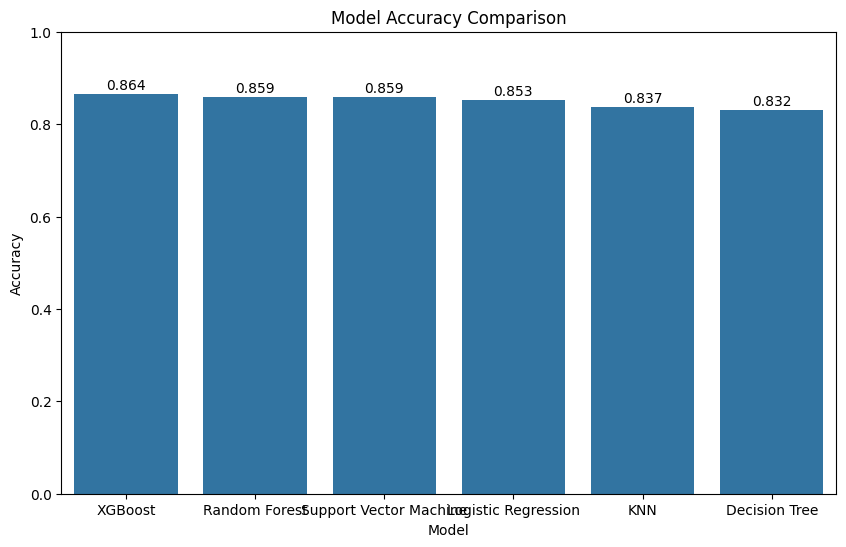

In [25]:
# Plot accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
for i, row in results_df.iterrows():
    plt.text(i, row['Accuracy'] + 0.01, f"{row['Accuracy']:.3f}", ha='center')
plt.show()

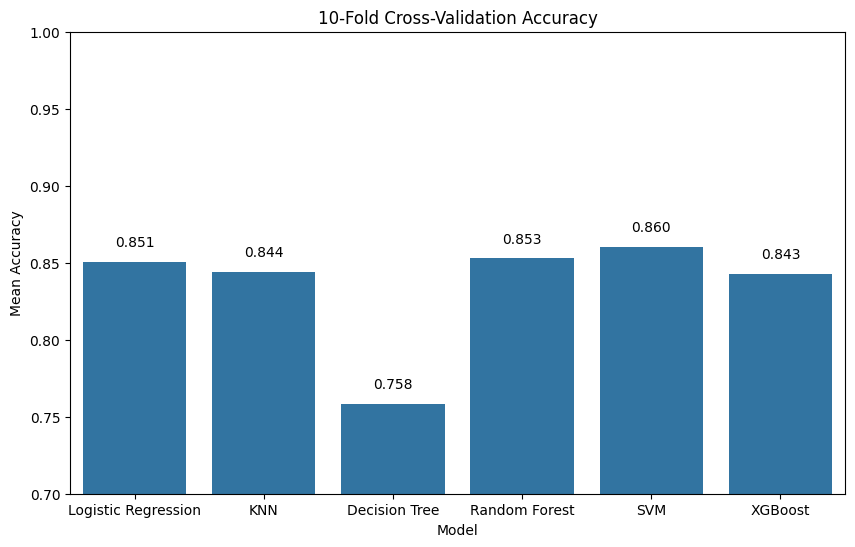

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=cv_df, x="Model", y="Mean Accuracy")

plt.title("10-Fold Cross-Validation Accuracy")
plt.ylim(0.7, 1.0)

for i, row in cv_df.iterrows():
    plt.text(i, row["Mean Accuracy"] + 0.01,
             f"{row['Mean Accuracy']:.3f}",
             ha='center')

plt.show()

# 🏆 Best Model Evaluation (Support Vector Machine)

After comparing multiple machine learning algorithms, the Support Vector Machine (SVM) achieved the highest overall performance.

This section provides a detailed evaluation of the selected model using several performance metrics and visualizations.

## Classification Report

The classification report summarizes the model's performance using:

- Precision
- Recall
- F1-Score
- Support

These metrics provide a more detailed evaluation than accuracy alone.

In [33]:

xgb_model_prediction = xgb_model.predict(X_test)

print(classification_report(y_test, xgb_model_prediction))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



## Confusion Matrix

The confusion matrix visualizes the number of correct and incorrect predictions made by the SVM model.

It helps identify:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

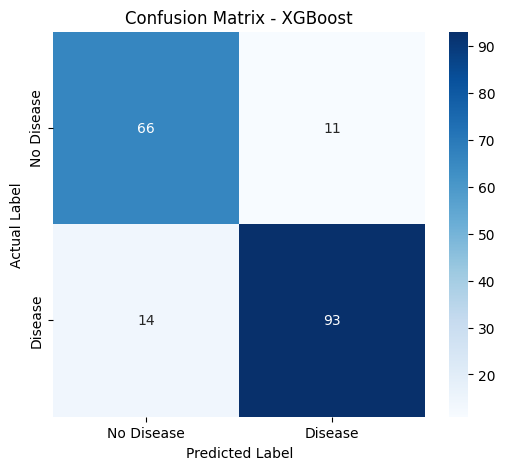

In [34]:

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGBoost")

plt.show()

## ROC Curve

The Receiver Operating Characteristic (ROC) Curve illustrates the ability of the SVM model to distinguish between patients with and without heart disease.

The Area Under the Curve (AUC) provides a single performance measure.

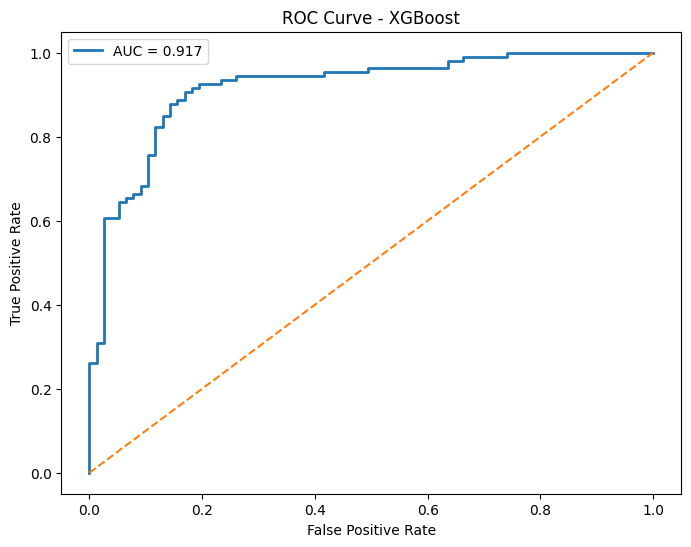

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

xgb_probability = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    xgb_probability
)

auc = roc_auc_score(
    y_test,
    xgb_probability
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.3f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

## Feature Importance

Permutation Importance measures the impact of each feature on the model's performance.

Features with higher importance contribute more significantly to the prediction of heart disease.

In [40]:


result = permutation_importance(
    svm_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Cholesterol,0.035326
14,ST_Slope_Up,0.032065
13,ST_Slope_Flat,0.029891
4,FastingBS,0.023913
7,Oldpeak,0.018478
8,ChestPainType_ATA,0.010326
0,Age,0.009783
2,RestingBP,0.005978
9,ChestPainType_NAP,0.005435
6,ExerciseAngina,0.004348


# Save the Best Model

The best-performing model is saved using Joblib so it can be loaded later by the prediction script and the Streamlit web application.

In [41]:
import joblib

joblib.dump(svm_model, "../models/heart_disease_model.pkl")

['../models/heart_disease_model.pkl']

In [42]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

# 🎯 Conclusion

In this project, multiple machine learning algorithms were developed and evaluated for heart disease prediction.

The workflow included:

- Data preprocessing
- Feature engineering
- Model training
- Hyperparameter tuning
- Cross-validation
- Performance comparison

The best-performing model was selected and exported for deployment in a Streamlit web application.